# Loading and Analyzing Old Experiment Data

Load saved `.h5` files as their original experiment objects using `ExperimentClass.from_h5file(path)`, then call `analyze()` and `display()` directly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from slab_qick_calib.experiments.single_qubit.t1 import T1Experiment
from slab_qick_calib.experiments.single_qubit.rabi import RabiExperiment
from slab_qick_calib.experiments.single_qubit.t2 import T2Experiment
from slab_qick_calib.experiments.single_qubit.pulse_probe_spectroscopy import QubitSpecFastFlux
from slab_qick_calib.experiments.single_qubit.resonator_spectroscopy import ResSpecPower
from slab_qick_calib.helpers import handy
%matplotlib inline
handy.config_figs()
DATA_DIR = "C:/_Data/sample_50_new/" #data"

<module 'slab_qick_calib.experiments' from 'C:\\_Lib\\python\\qq\\slab_qick_calib\\experiments\\__init__.py'>
C:\_Lib\python\qq\slab_qick_calib\experiments
imported slab_qick_calib.experiments.general.qick_experiment
imported slab_qick_calib.experiments.general.qick_experiment_2q
imported slab_qick_calib.experiments.general.qick_program
C:\_Lib\python\qq\slab_qick_calib\experiments\general
C:\_Lib\python\qq\slab_qick_calib\experiments\single_qubit
imported slab_qick_calib.experiments.single_qubit.active_reset
imported slab_qick_calib.experiments.single_qubit.power_calibration
imported slab_qick_calib.experiments.single_qubit.pulse_probe_spectroscopy
imported slab_qick_calib.experiments.single_qubit.rabi
imported slab_qick_calib.experiments.single_qubit.resonator_spectroscopy
imported slab_qick_calib.experiments.single_qubit.single_shot
imported slab_qick_calib.experiments.single_qubit.single_shot_opt
imported slab_qick_calib.experiments.single_qubit.stark_spectroscopy
imported slab_qic

In [2]:
import os
from dotenv import load_dotenv
from bluefors import BlueforsClient

load_dotenv()

client = BlueforsClient(
    host=os.environ["BLUEFORS_HOST"],
    port=int(os.environ["BLUEFORS_PORT"]),
    api_key=os.environ["BLUEFORS_API_KEY"],
    verify_ssl=False,
    timeout=60,
)

In [3]:
# mxc_temp = client.get_mxc_temperature()
# print(f"MXC Temperature: {mxc_temp:.6f} K ({mxc_temp * 1000:.2f} mK)")

In [4]:

qsff = QubitSpecFastFlux.from_h5file(f"{DATA_DIR}/data/qspec_fastflux_qubit2_00032.h5")
#qspec_fastflux_qubit2_00032.h5


In [5]:
qsff.data.keys()

dict_keys(['amps', 'avgi', 'avgq', 'best_fit', 'bin_centers', 'f_ge_max', 'fit_amps', 'fit_avgi', 'fit_avgq', 'fit_err', 'fit_err_amps', 'fit_err_avgi', 'fit_err_avgq', 'fit_err_par', 'fit_init_amps', 'fit_init_avgi', 'fit_init_avgq', 'freq_coeffs', 'freq_fit', 'gain_pts', 'gain_sweet_spot', 'hist', 'i_best', 'kappa_list', 'new_freq', 'phases', 'qubit_freq_list', 'r2', 'scale_data', 'start_time', 'time', 'transmon_fit', 'transmon_params', 'xpts', 'attrs'])

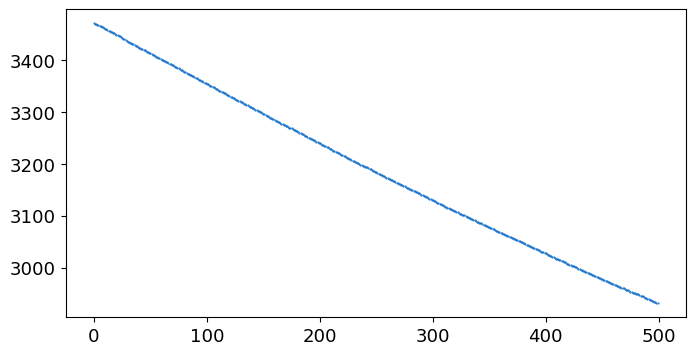

In [6]:
plt.figure()
plt.plot(qsff.data['qubit_freq_list'],'.', markersize=1)
plt.show()

In [7]:
qsff.data['xpts']

array([[3453.50000044, 3454.01020397, 3454.52040751, ..., 3477.4795665 ,
        3477.98977003, 3478.49997356],
       [3459.0808675 , 3459.59107103, 3460.10127457, ..., 3483.06043356,
        3483.57063709, 3484.08084063],
       [3458.34571444, 3458.85591797, 3459.3661215 , ..., 3482.32528049,
        3482.83548403, 3483.34568756],
       ...,
       [2921.33369888, 2921.84390242, 2922.35410595, ..., 2945.31326494,
        2945.82346848, 2946.33367201],
       [2920.512665  , 2921.02286854, 2921.53307207, ..., 2944.49223106,
        2945.0024346 , 2945.51263813],
       [2919.25868105, 2919.76888458, 2920.27908812, ..., 2943.23824711,
        2943.74845064, 2944.25865417]])

C:\Users\circu\AppData\Local\Temp\ipykernel_383632\1872883080.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax_flip.pcolormesh(y_gain_flip, x_vals_flip, avgi, shading="nearest")


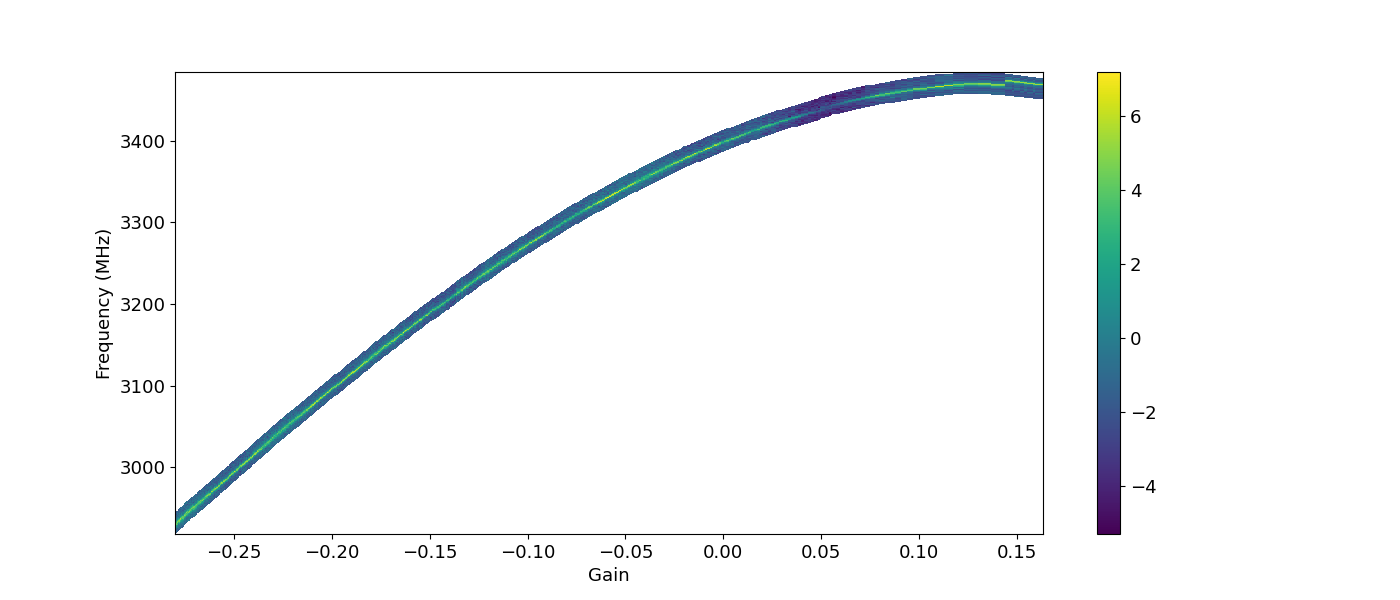

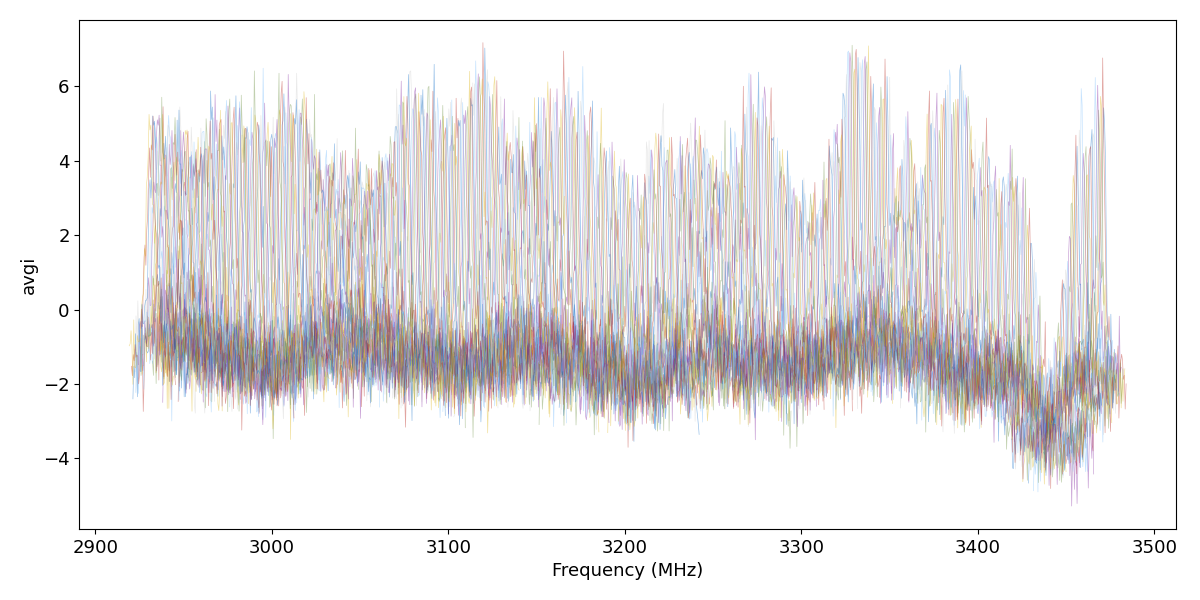

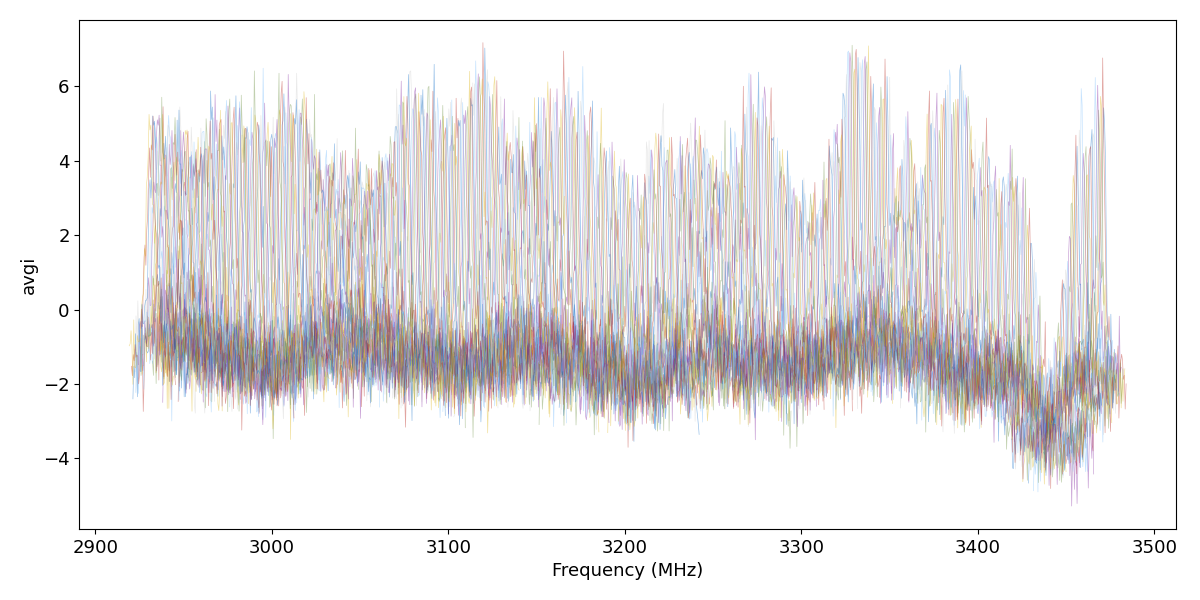

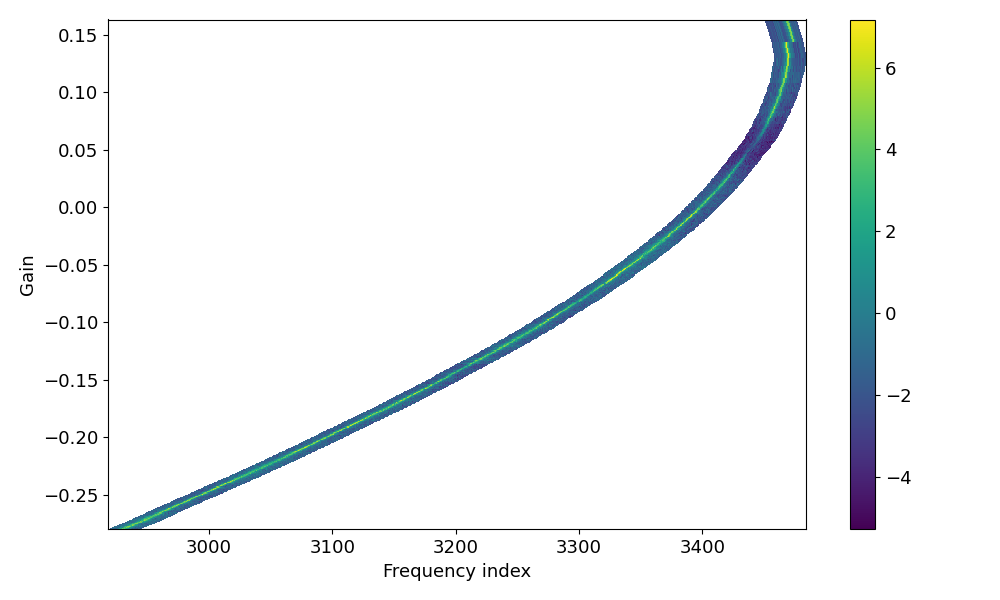

In [13]:
%matplotlib widget
plt.figure(figsize=(10, 6))
avgi = qsff.data["avgi"]
n_rows, n_cols = avgi.shape

# Keep the pre-created figure active for the original plot below
_base_fig = plt.gcf()

# Additional plot with flipped axes (x=gain, y=frequency)
x_vals_flip = qsff.data["xpts"]
y_gain_flip = np.repeat(qsff.data["gain_pts"][:, None], n_cols, axis=1)

fig_flip, ax_flip = plt.subplots(figsize=(14, 6))
pcm = ax_flip.pcolormesh(y_gain_flip, x_vals_flip, avgi, shading="nearest")
ax_flip.set_xlabel("Gain")
ax_flip.set_ylabel("Frequency (MHz)")
fig_flip.colorbar(pcm, ax=ax_flip)
plt.show()

# Restore original figure so existing plot code continues unchanged
plt.figure(_base_fig.number)

# Row-dependent frequency index: row 0 -> 1..n_cols, row 1 -> 2..n_cols+1, ...
x_idx = np.arange(1, n_cols + 1)[None, :] + np.arange(n_rows)[:, None]
y_gain = np.repeat(qsff.data["gain_pts"][:, None], n_cols, axis=1)
x_vals = qsff.data["xpts"]
plt.pcolormesh(x_vals, y_gain, avgi, shading="nearest")
plt.xlabel("Frequency index")
plt.ylabel("Gain")
plt.colorbar()

plt.tight_layout()

# Line plots for all rows in avgi
fig_lines, ax_lines = plt.subplots(figsize=(12, 6))
for i in range(n_rows):
    ax_lines.plot(x_vals[i], avgi[i], lw=0.5, alpha=0.4)
ax_lines.set_xlabel("Frequency (MHz)")
ax_lines.set_ylabel("avgi")
plt.tight_layout()
plt.show()
plt.show()

In [9]:
x_idx

array([[  1,   2,   3, ...,  48,  49,  50],
       [  2,   3,   4, ...,  49,  50,  51],
       [  3,   4,   5, ...,  50,  51,  52],
       ...,
       [498, 499, 500, ..., 545, 546, 547],
       [499, 500, 501, ..., 546, 547, 548],
       [500, 501, 502, ..., 547, 548, 549]])

## 1. T1 Experiment

Load a T1 file as a `T1Experiment` object, re-analyze, and display using its own methods.

In [10]:
t1 = T1Experiment.from_h5file(f"{DATA_DIR}/t1_qubit0_00011.h5")
t1.analyze(get_hist=False)
t1.display()

AssertionError: Path C:/_Data/sample_50_new//t1_qubit0_00011.h5 does not exist

## 2. Rabi Experiment

R2:0.897	Fit par error:0.490	 Best fit:b'amps'


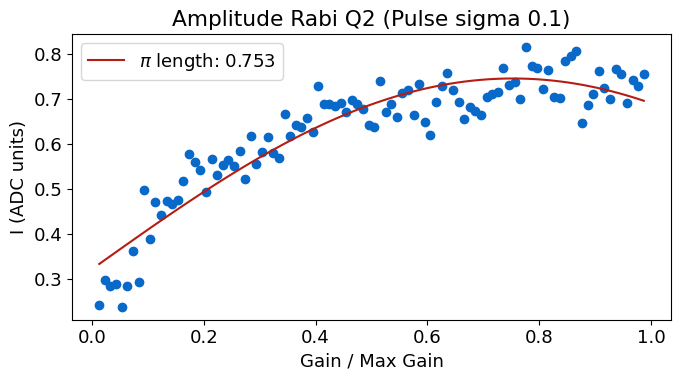

In [ ]:
rabi = RabiExperiment.from_h5file(f"{DATA_DIR}/amp_rabi_qubit2_00008.h5")
rabi.analyze(get_hist=False)
rabi.display()

## 3. Ramsey (T2) Experiment

R2:0.868	Fit par error:0.073	 Best fit:b'avgi'


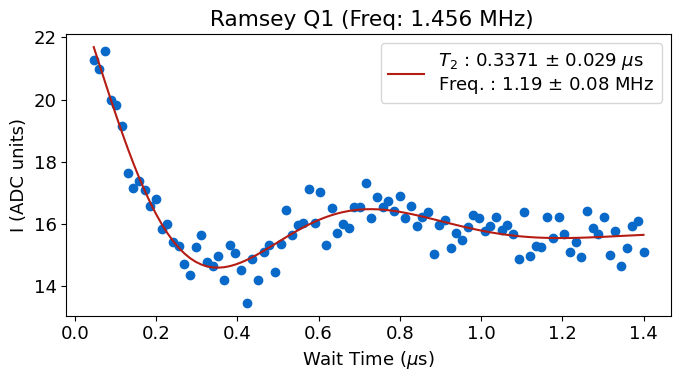

In [ ]:
ramsey = T2Experiment.from_h5file(f"{DATA_DIR}/ramsey_qubit1_00008.h5")
ramsey.analyze(get_hist=False)
ramsey.display()

## 4. Qubit Power Spectroscopy

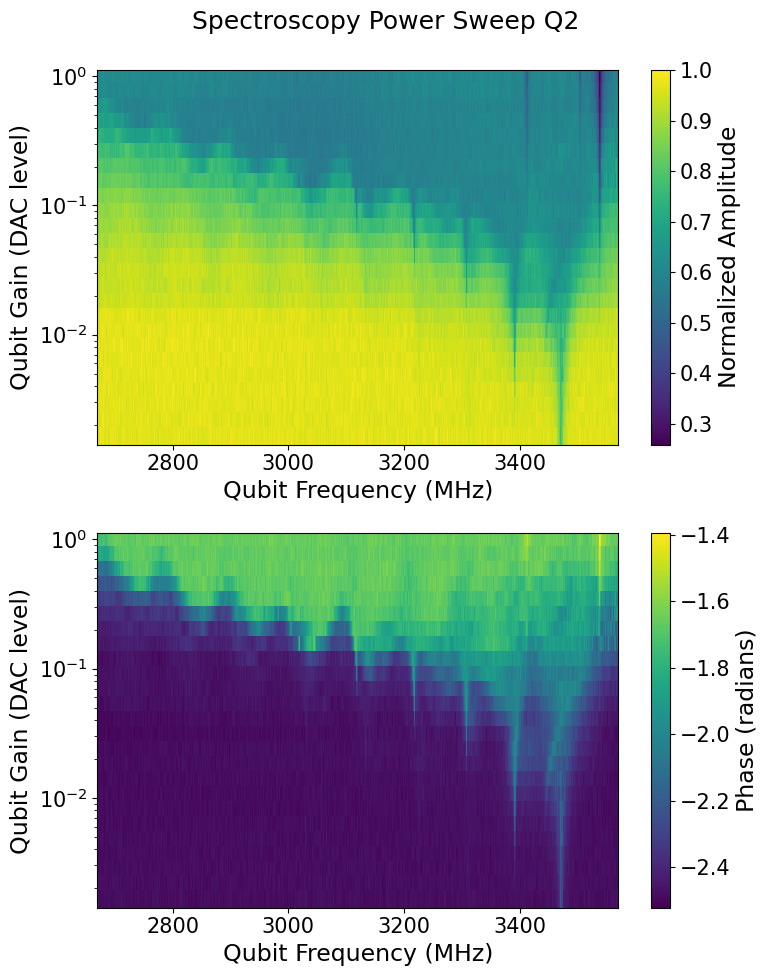

In [ ]:
DATA_DIR = "C:/_Data/sample_50/data"
from slab_qick_calib.experiments.single_qubit.pulse_probe_spectroscopy import QubitSpecPower

#qsp = QubitSpecPower.from_h5file(f"{DATA_DIR}/qubit_spectroscopy_power_coarse_qubit1_00004.h5")
#qsp = QubitSpecPower.from_h5file(f"{DATA_DIR}/qubit_spectroscopy_power_coarse_qubit2_00001.h5")
qsp = QubitSpecPower.from_h5file(f"{DATA_DIR}/qubit_spectroscopy_power_coarse_qubit2_00006.h5")
qsp.analyze()
qsp.display(display='talk', normalize=True)

=== 2D (summed over all gains) — top 6 peaks ===
  1. 3056.6 MHz
  2. 3139.7 MHz
  3. 3308.1 MHz
  4. 3391.9 MHz
  5. 3470.2 MHz
  6. 3538.8 MHz

=== 1D (max-gain row, gain=1.000) — top 6 peaks ===
  1. 3064.2 MHz
  2. 3142.5 MHz
  3. 3285.9 MHz
  4. 3413.4 MHz
  5. 3504.2 MHz
  6. 3538.1 MHz

top6_2d = [3056.6, 3139.7, 3308.1, 3391.9, 3470.2, 3538.8]
top6_1d = [3064.2, 3142.5, 3285.9, 3413.4, 3504.2, 3538.1]


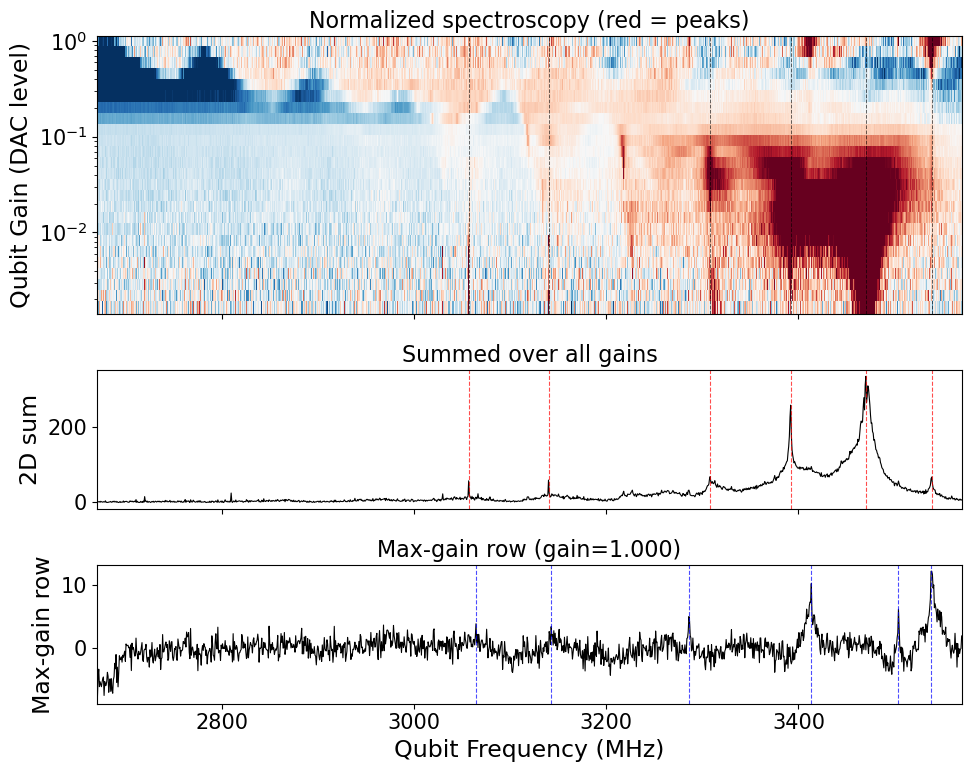

In [ ]:
# Find peak frequencies across the full 2D power spectroscopy dataset.
npeaks=6
from scipy.signal import find_peaks

amps = qsp.data["avgi"]
xpts = qsp.data["xpts"]
ypts = qsp.data["ypts"]

# Normalize each row: subtract median, divide by MAD
normed = np.zeros_like(amps)
for i in range(amps.shape[0]):
    row = amps[i]
    med = np.median(row)
    mad = np.median(np.abs(row - med))
    if mad > 0:
        normed[i] = (row - med) / mad
    else:
        normed[i] = row - med

# ypts is descending: row 0 = max gain, row -1 = min gain
max_gain_idx = 0

# --- 2D analysis: sum positive deviations across all gains ---
peak_strength = np.sum(np.clip(normed, 0, None), axis=0)
p_2d, pr_2d = find_peaks(peak_strength, distance=10, prominence=0)
order_2d = np.argsort(pr_2d["prominences"])[::-1]
p_2d_sorted = p_2d[order_2d]
top6_2d = np.sort(xpts[p_2d_sorted[:npeaks]])

print("=== 2D (summed over all gains) — top 6 peaks ===")
for i, f in enumerate(top6_2d):
    print(f"  {i+1}. {f:.1f} MHz")

# --- 1D analysis: max-gain row (row 0) ---
max_gain_trace = normed[max_gain_idx]
p_1d, pr_1d = find_peaks(max_gain_trace, distance=10, prominence=0)
order_1d = np.argsort(pr_1d["prominences"])[::-1]
p_1d_sorted = p_1d[order_1d]
top6_1d = np.sort(xpts[p_1d_sorted[:npeaks]])

print(f"\n=== 1D (max-gain row, gain={ypts[max_gain_idx]:.3f}) — top 6 peaks ===")
for i, f in enumerate(top6_1d):
    print(f"  {i+1}. {f:.1f} MHz")

print(f"\ntop6_2d = {np.array2string(top6_2d, precision=1, separator=', ')}")
print(f"top6_1d = {np.array2string(top6_1d, precision=1, separator=', ')}")

# --- Visualization ---
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1, 1]})

ax = axes[0]
ax.pcolormesh(xpts, ypts, normed, shading="auto", cmap="RdBu_r", vmin=-5, vmax=5)
ax.set_yscale("log")
ax.set_ylabel("Qubit Gain (DAC level)")
ax.set_title("Normalized spectroscopy (red = peaks)")
for f in top6_2d:
    ax.axvline(f, color="k", ls="--", lw=0.7, alpha=0.6)

ax = axes[1]
ax.plot(xpts, peak_strength, "k-", lw=0.8)
ax.set_ylabel("2D sum")
ax.set_title("Summed over all gains")
for f in top6_2d:
    ax.axvline(f, color="r", ls="--", lw=0.8, alpha=0.7)

ax = axes[2]
ax.plot(xpts, max_gain_trace, "k-", lw=0.8)
ax.set_ylabel("Max-gain row")
ax.set_xlabel("Qubit Frequency (MHz)")
ax.set_title(f"Max-gain row (gain={ypts[max_gain_idx]:.3f})")
for f in top6_1d:
    ax.axvline(f, color="b", ls="--", lw=0.8, alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
peaks = np.array([4238.13753462,  4402.80147989,
       4543.94200441])
#top6_1d

In [ ]:
peaks

array([4238.13753462, 4402.80147989, 4543.94200441])

In [ ]:
3391.9-3538.8

-146.9000000000001

In [ ]:
top6_2d

array([4238.13753462, 4321.22025473, 4402.80147989, 4477.37572866,
       4543.94200441, 4571.96990999])

In [ ]:
#top6_2d

from numpy.char import array


np.diff(np.array([3042.28508663,
 3234.94551659, 
       3398.41497231]))

array([192.66042996, 163.46945572])

In [ ]:
all_the_peaks = np.array([4147.5, 4238.1, 4321.2, 4402.8, 4477.4, 4543.9])
np.diff(all_the_peaks)


array([90.6, 83.1, 81.6, 74.6, 66.5])

In [ ]:
all_the_peaks = np.array([3042. , 3154.2, 3234.7, 3319.3,3398.4])
np.diff(all_the_peaks)


array([112.2,  80.5,  84.6,  79.1])

In [ ]:
84.6+ 79.1

163.7

In [ ]:
74.6+66.5
81.6+ 74.6
90.6+ 83.1

173.7

## 5. Compare multiple T1 measurements

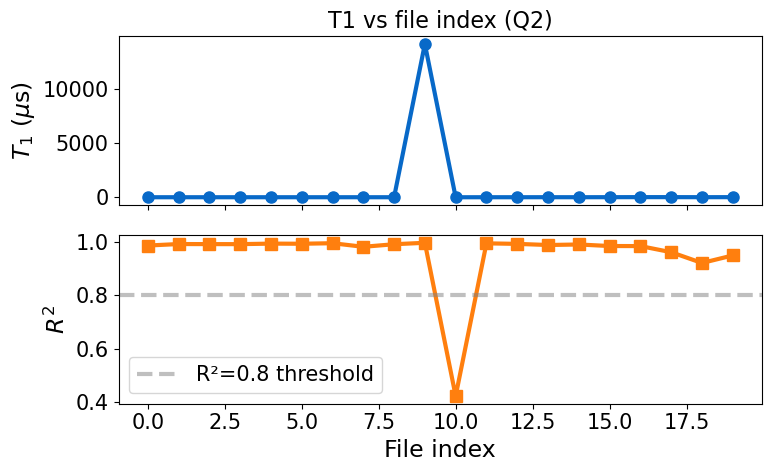

In [ ]:
t1_results = []
for i in range(20):
    fpath = f"{DATA_DIR}/t1_qubit2_{i:05d}.h5"
    try:
        exp = T1Experiment.from_h5file(fpath)
        exp.analyze(verbose=False, get_hist=False)
        t1_results.append({
            "index": i,
            "T1": exp.data["new_t1"],
            "r2": exp.data["r2"],
        })
    except Exception:
        pass

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
indices = [r["index"] for r in t1_results]
t1_vals = [r["T1"] for r in t1_results]
r2_vals = [r["r2"] for r in t1_results]

ax1.plot(indices, t1_vals, "o-")
ax1.set_ylabel("$T_1$ ($\\mu$s)")
ax1.set_title("T1 vs file index (Q2)")

ax2.plot(indices, r2_vals, "s-", color="tab:orange")
ax2.set_ylabel("$R^2$")
ax2.set_xlabel("File index")
ax2.axhline(0.8, color="gray", ls="--", alpha=0.5, label="R²=0.8 threshold")
ax2.legend()
plt.tight_layout()
plt.show()

R2:0.841	Fit par error:0.189	 Best fit:b'avgi'


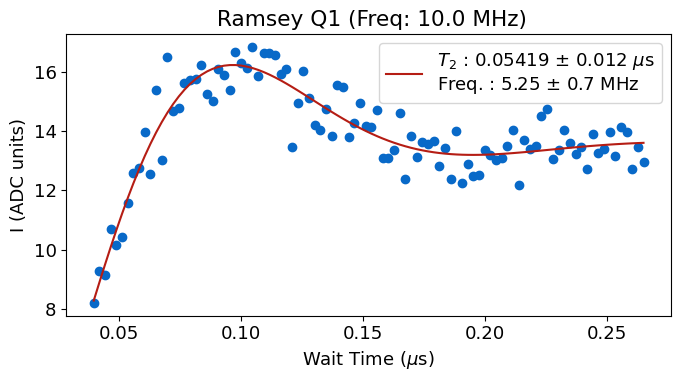

In [ ]:
ramsey = T2Experiment.from_h5file(f"{DATA_DIR}/ramsey_qubit1_00008.h5")
ramsey.analyze(get_hist=False)
ramsey.display()

## 6. Resonator Power Sweep

In [ ]:
#rsp = ResSpecPower.from_h5file(f"{DATA_DIR}/resonator_spectroscopy_power_sweep_qubit1_00003.h5")
rsp = ResSpecPower.from_h5file(f"{DATA_DIR}/resonator_spectroscopy_power_sweep_qubit2_00004.h5")
rsp.analyze()
rsp.display()

AssertionError: Path C:/_Data/sample_50/data/resonator_spectroscopy_power_sweep_qubit2_00004.h5 does not exist

In [ ]:
rsp.data['amps'].shape

(76, 300)

Gain range: 0.0100 to 1.0000  (20 steps, log-spaced)

Low-gain resonance frequency: 7681.8737 MHz
  (over gains 0.0100 – 0.0886)
High-gain resonance frequency: 7675.8303 MHz
  (over gains 0.1129 – 1.0000)



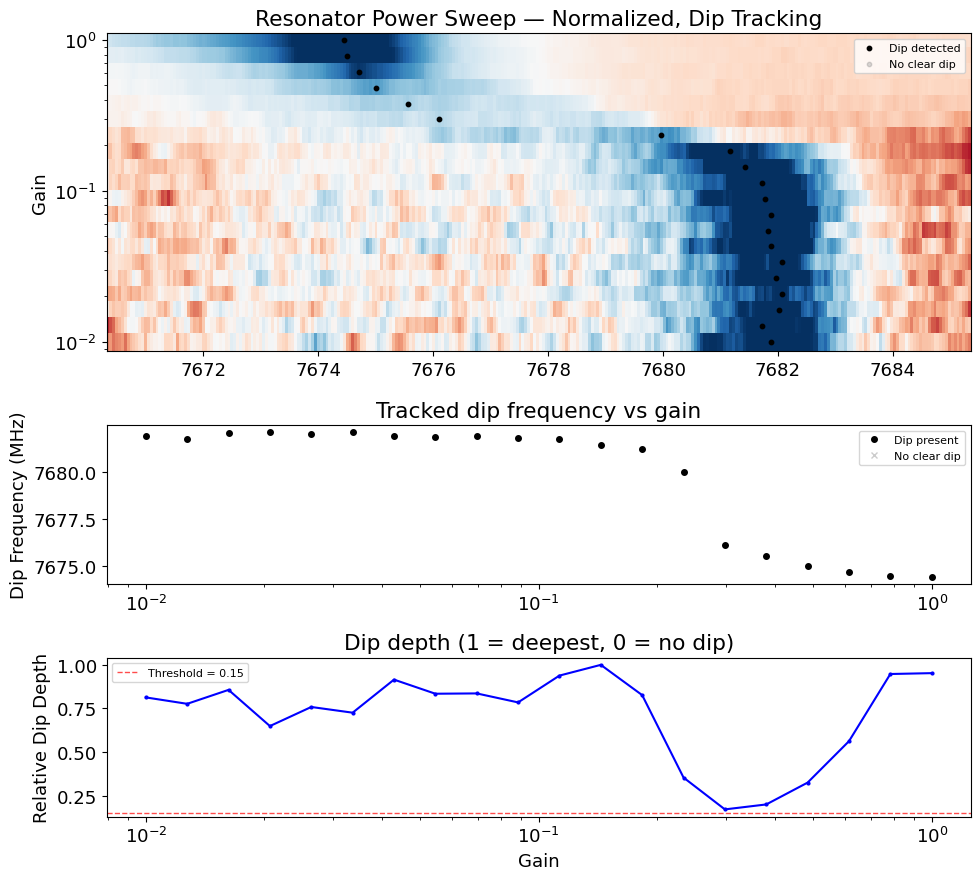

In [ ]:

# --- Resonator power sweep: track the dip across gains ---
from scipy.ndimage import uniform_filter1d

amps = rsp.data['amps']      # shape (n_gains, n_freqs)
xpts = rsp.data['xpts']      # frequencies in MHz
gain_pts = rsp.data['gain_pts']  # gain values

n_gains, n_freqs = amps.shape

# Sort by gain (ascending)
sort_idx = np.argsort(gain_pts)
gains_sorted = gain_pts[sort_idx]
amps_sorted = amps[sort_idx]

# Normalize each row: subtract median, divide by MAD
normed = np.zeros_like(amps_sorted)
for i in range(n_gains):
    row = uniform_filter1d(amps_sorted[i], size=5)
    med = np.median(row)
    mad = np.median(np.abs(row - med))
    normed[i] = (row - med) / mad if mad > 0 else row - med

# For each gain, find the deepest dip in normalized data
dip_freqs = np.full(n_gains, np.nan)
dip_depths = np.full(n_gains, np.nan)  # will be negative for dips

for i in range(n_gains):
    min_idx = np.argmin(normed[i])
    dip_freqs[i] = xpts[min_idx]
    dip_depths[i] = normed[i, min_idx]

# Relative dip strength: most negative = strongest dip -> rel_depth=1
max_depth = np.min(dip_depths)
rel_depth = dip_depths / max_depth  # 1 = deepest, ~0 = no dip

# Threshold for "resonance present"
threshold = 0.15
present = rel_depth > threshold

# Find transitions: present -> absent -> present
transitions = np.diff(present.astype(int))
disappear_idx = np.where(transitions == -1)[0]
reappear_idx = np.where(transitions == 1)[0]

print(f"Gain range: {gains_sorted[0]:.4f} to {gains_sorted[-1]:.4f}  ({n_gains} steps, log-spaced)")
print()

# Low-gain resonance frequency
low_gain_present = np.where(present[:n_gains//2])[0]
if len(low_gain_present) > 0:
    low_gain_freq = np.median(dip_freqs[low_gain_present])
    print(f"Low-gain resonance frequency: {low_gain_freq:.4f} MHz")
    print(f"  (over gains {gains_sorted[low_gain_present[0]]:.4f} – {gains_sorted[low_gain_present[-1]]:.4f})")

# High-gain resonance frequency
high_gain_present = np.where(present[n_gains//2:])[0] + n_gains//2
if len(high_gain_present) > 0:
    high_gain_freq = np.median(dip_freqs[high_gain_present])
    print(f"High-gain resonance frequency: {high_gain_freq:.4f} MHz")
    print(f"  (over gains {gains_sorted[high_gain_present[0]]:.4f} – {gains_sorted[high_gain_present[-1]]:.4f})")

print()
g_disappear = g_reappear = None
if len(disappear_idx) > 0:
    g_disappear = gains_sorted[disappear_idx[0]]
    print(f"Resonance DISAPPEARS at gain ~ {g_disappear:.4f}"
          f" (between {gains_sorted[disappear_idx[0]]:.4f} and {gains_sorted[disappear_idx[0]+1]:.4f})")
if len(reappear_idx) > 0:
    for ri in reappear_idx:
        if len(disappear_idx) == 0 or ri > disappear_idx[0]:
            g_reappear = gains_sorted[ri + 1]
            print(f"Resonance REAPPEARS  at gain ~ {g_reappear:.4f}"
                  f" (between {gains_sorted[ri]:.4f} and {gains_sorted[ri+1]:.4f})")
            break

if g_disappear is not None and g_reappear is not None:
    print(f"\nNo-resonance gap: gain {g_disappear:.4f} – {g_reappear:.4f}")

# --- Plots (normalized data, log-scale gain axis) ---
fig, axes = plt.subplots(3, 1, figsize=(10, 9), gridspec_kw={"height_ratios": [2, 1, 1]})

# Panel 1: normalized 2D color plot
ax = axes[0]
ax.pcolormesh(xpts, gains_sorted, normed, shading="auto", cmap="RdBu_r", vmin=-5, vmax=5)
ax.set_yscale("log")
ax.scatter(dip_freqs[present], gains_sorted[present], c='k', s=10, zorder=3, label='Dip detected')
ax.scatter(dip_freqs[~present], gains_sorted[~present], c='gray', s=10, alpha=0.3, zorder=3, label='No clear dip')
if g_disappear is not None:
    ax.axhline(g_disappear, color='orange', ls='--', lw=1.5, label=f'Disappears ~{g_disappear:.4f}')
if g_reappear is not None:
    ax.axhline(g_reappear, color='lime', ls='--', lw=1.5, label=f'Reappears ~{g_reappear:.4f}')
ax.set_ylabel("Gain")
ax.set_title("Resonator Power Sweep — Normalized, Dip Tracking")
ax.legend(fontsize=8, loc='upper right')

# Panel 2: dip frequency vs gain (log x)
ax = axes[1]
ax.semilogx(gains_sorted[present], dip_freqs[present], 'ko', ms=4, label='Dip present')
ax.semilogx(gains_sorted[~present], dip_freqs[~present], 'x', color='gray', ms=4, alpha=0.4, label='No clear dip')
ax.set_ylabel("Dip Frequency (MHz)")
ax.set_title("Tracked dip frequency vs gain")
ax.legend(fontsize=8)

# Panel 3: relative dip depth vs gain (log x)
ax = axes[2]
ax.semilogx(gains_sorted, rel_depth, 'b.-', ms=4)
ax.axhline(threshold, color='r', ls='--', lw=1, alpha=0.7, label=f'Threshold = {threshold}')
ax.set_ylabel("Relative Dip Depth")
ax.set_xlabel("Gain")
ax.set_title("Dip depth (1 = deepest, 0 = no dip)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
